In [41]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor

In [42]:
# 価格を生成する関数
def create_price(r_min: float, r_max: float, M: int) -> NDArray[np.float_]:
    # r_minとr_maxの間のランダムな0.1刻みの少数をM個生成
    price = np.random.uniform(r_min, r_max, M)
    price = np.round(price, 1)

    return price


# alphaを作成する関数
def alpha_star(M: int) -> NDArray[np.float_]:
    alpha_star = np.random.uniform(M, 3 * M, size=M)
    return alpha_star


# betaを作成する関数
def beta_star(M: int, M_prime: int) -> NDArray[np.float_]:
    beta_star = np.zeros((M, M_prime))

    for m in range(M):
        for m_prime in range(M_prime):
            if m == m_prime:
                beta_star[m, m_prime] = np.random.uniform(-2 * M, -M)
            else:
                beta_star[m, m_prime] = np.random.uniform(0, 1)

    return beta_star


def quantity_function(
    price: NDArray[np.float_], alpha: NDArray[np.float_], beta: NDArray[np.float_]
) -> list[float]:
    M = len(price)
    quantity_list = []

    for m in range(M):
        sum_beta = 0
        for m_prime in range(M):
            sum_beta += beta[m][m_prime] * price[m_prime]

        quantity = alpha[m] + sum_beta + 1 * np.random.normal(0, 5)
        quantity_list.append(quantity)
    print("quantity_list", quantity_list)

    return quantity_list


def sales_function(
    price: NDArray[np.float_], alpha: NDArray[np.float_], beta: NDArray[np.float_]
) -> list[float]:
    M = len(price)
    sales_list = []

    for m in range(M):
        sum_beta = 0
        for m_prime in range(M):
            sum_beta += beta[m][m_prime] * price[m_prime]

        quantity = alpha[m] + sum_beta
        sales_list.append(quantity * price[m])

    return sales_list

In [43]:
from scipy.optimize import minimize


# 予測と最適化を行う関数
def predict_optimize(
    M: int, X: NDArray[np.float_], Y: NDArray[np.float_], prices_list: list[float]
) -> tuple[float, NDArray[np.float_]]:
    lr = MultiOutputRegressor(LinearRegression())
    lr.fit(X, Y)
    # 係数と切片を取得
    coefs = [estimate.coef_ for estimate in lr.estimators_]
    intercepts = [estimate.intercept_ for estimate in lr.estimators_]

    def objective_function(prices):
        return -sum(
            prices[m]
            * (
                intercepts[m]
                + sum(coefs[m][m_prime] * prices[m_prime] for m_prime in range(M))
            )
            for m in range(M)
        )

    # 初期値として与えられたprices_listを使用
    initial_prices = np.full(M, 0.6)
    # 各価格の範囲を設定（0.6から1.0）
    bounds = [(0.6, 1.0) for _ in range(M)]
    # 最適化を実行
    result = minimize(objective_function, initial_prices, bounds=bounds, method="SLSQP")
    # 最適な価格と目的関数の値を取得
    optimal_prices = result.x
    optimal_value = -result.fun  # 符号を反転して元の最大化問題の値に戻す
    return optimal_value, optimal_prices

In [44]:
# # sales_optimizeの最適化を行う関数
# def sales_optimize(
#     M: int,
#     alpha: NDArray[np.float_],
#     beta: NDArray[np.float_],
#     prices_list: list[float],
# ) -> tuple[float, NDArray[np.float_]]:
#     objective = sum(
#         prices_list[m]
#         * (
#             alpha[m]
#             + sum(beta[m][m_prime] * prices_list[m_prime] for m_prime in range(M))
#         )
#         for m in range(M)
#     )
#     # objectiveを最大にする価格を求める
import numpy as np


# sales_optimizeの最適化を行う関数
def sales_optimize(
    M: int,
    alpha: np.ndarray,
    beta: np.ndarray,
    prices_list: list[float],
) -> tuple[float, np.ndarray]:
    # 目的関数を定義（最大化問題を最小化問題に変換）
    def objective_function(prices):
        return -sum(
            prices[m]
            * (
                alpha[m]
                + sum(beta[m][m_prime] * prices[m_prime] for m_prime in range(M))
            )
            for m in range(M)
        )

    # 初期値として与えられたprices_listを使用
    initial_prices = np.full(M, 0.6)
    # 各価格の範囲を設定（0.6から1.0）
    bounds = [(0.6, 1.0) for _ in range(M)]
    # 最適化を実行
    result = minimize(objective_function, initial_prices, bounds=bounds, method="SLSQP")
    # 最適な価格と目的関数の値を取得
    optimal_prices = result.x
    optimal_value = -result.fun  # 符号を反転して元の最大化問題の値に戻す
    return optimal_value, optimal_prices

In [45]:
# CVを行う関数
def cross_validation(
    X: NDArray[np.float_],
    y: NDArray[np.float_],
    M: int,
    K: int,
    prices_list: list[float],
) -> float:
    kf = KFold(n_splits=K, shuffle=True, random_state=0)
    optimal_sales_list = []
    Z = len(prices_list)

    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # trainで学習
        lr_tilda = MultiOutputRegressor(LinearRegression())

        # 係数、切片を取得
        lr_tilda.fit(X_train, y_train)
        coefs = [estimate.coef_ for estimate in lr_tilda.estimators_]
        intercepts = [estimate.intercept_ for estimate in lr_tilda.estimators_]

        def objective_function(prices):
            return -sum(
                prices[m]
                * (
                    intercepts[m]
                    + sum(coefs[m][m_prime] * prices[m_prime] for m_prime in range(M))
                )
                for m in range(M)
            )

        # 初期値として与えられたprices_listを使用
        initial_prices = np.full(M, 0.6)
        # 各価格の範囲を設定（0.6から1.0）
        bounds = [(0.6, 1.0) for _ in range(M)]
        # 最適化を実行
        result = minimize(
            objective_function, initial_prices, bounds=bounds, method="SLSQP"
        )
        # 最適な価格と目的関数の値を取得
        optimal_prices = result.x
        optimal_value = -result.fun  # 符号を反転して元の最大化問題の値に戻す

        # testで学習
        lr_hat = MultiOutputRegressor(LinearRegression())
        lr_hat.fit(X_test, y_test)

        quantity_hat = lr_hat.predict([optimal_prices])
        sales_hat = np.sum(quantity_hat * optimal_prices)

        optimal_sales_list.append(sales_hat)

    return np.mean(optimal_sales_list)

In [46]:
# このデータにおけるalpha,betaを作成
M = 50
alpha = alpha_star(M)
beta = beta_star(M, M)
r_m = 0.6
r_M = 1.0
# 価格を入れるリスト
price_list = []
# 売上を入れるリスト
sales_list = []

# 価格と対応する売上を500件生成
for i in range(500):
    price = create_price(r_m, r_M, M)
    price_list.append(price)
    sales = quantity_function(price, alpha, beta)
    sales_list.append(sales)

X = np.array(price_list).astype(float)
y = np.array(sales_list).astype(float)

quantity_list [53.26757535400026, 51.43418801959256, 30.445833416857983, 112.4192143036393, 39.59021813488955, 9.784112596753811, 36.54060792469811, 103.34871518886816, 101.21269590793493, 99.45335068381775, 103.27134658932144, 102.33159516281262, 26.23403026598218, 42.3078430582191, 39.361239772046424, 74.09975581584116, 64.5083324209447, 6.057426942960307, 18.26619707649206, 37.774751818005406, -18.013257868306532, 79.93970862855457, 63.514772815154956, 34.376994623375055, 38.083704226387574, 96.32071203344859, 50.74920707270166, 67.58982681156559, 2.2762592544902684, 57.84159931876064, 53.50053706837425, 26.66448775547424, 65.43529147208366, 100.01706927071082, 108.59662439158366, 94.39266527114728, -2.8253097565854173, 28.90565144138739, 54.80417037803736, 44.57078210815309, 83.20867112965357, 54.17249367694944, 37.760595530375326, 70.34659536775943, 25.230416492032653, 63.344777682627345, 70.59923889642097, 15.922254976236616, 70.81921665935617, 56.330123554927304]
quantity_list [

In [47]:
z = [0.6, 0.7, 0.8, 0.9, 1.0]

In [48]:
predict_optimize(M, X, y, z)

(2412.317026774579,
 array([0.94903518, 1.        , 0.6       , 1.        , 0.63757546,
        0.64575819, 0.67662462, 1.        , 1.        , 1.        ,
        1.        , 1.        , 0.83798669, 1.        , 0.80905099,
        0.97457954, 1.        , 0.6518966 , 0.65407147, 1.        ,
        0.6       , 1.        , 1.        , 0.76627198, 0.70803658,
        1.        , 0.79576821, 0.87704343, 0.65105491, 0.99291491,
        1.        , 0.60171806, 0.98568398, 1.        , 1.        ,
        1.        , 0.72417553, 0.80641012, 1.        , 0.89764037,
        1.        , 0.86168845, 0.7372174 , 1.        , 0.76283264,
        0.84929213, 1.        , 0.6       , 1.        , 1.        ]))

In [49]:
# cross_validation(X, y, M, 5, z)

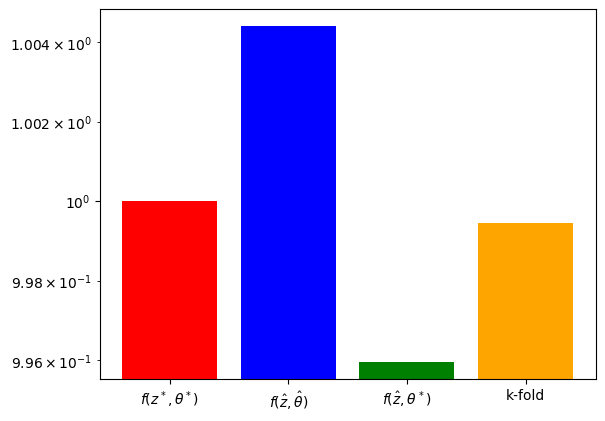

In [50]:
# predict_optimazeの結果を取得
predict_optimize_sales, predict_optimize_prices = predict_optimize(M, X, y, z)
# sales_optimizeの結果を取得
sales_optimize_sales, sales_optimize_prices = sales_optimize(M, alpha, beta, z)
# cross_validationの結果を取得
cross_validation_sales = cross_validation(X, y, M, 5, z)

# predictoptimize_salesをsales_functionに代入
predict_sales = sum(sales_function(predict_optimize_prices, alpha, beta))

# 結果を図示
plt.bar(
    [
        r"$f(z^*,\theta^*)$",
        r"$f(\hat{z},\hat\theta)$",
        r"$f(\hat{z},\theta^*)$",
        r"k-fold",
    ],
    [
        sales_optimize_sales / sales_optimize_sales,
        predict_optimize_sales / sales_optimize_sales,
        predict_sales / sales_optimize_sales,
        cross_validation_sales / sales_optimize_sales,
    ],
    color=["red", "blue", "green", "orange"],
)
plt.yscale("log")

plt.show()